# GigaTIME / GigaTIME-Flash — TCGA Slide-Level Inference

This notebook runs **whole-slide** virtual-mIF inference on a TCGA H&E slide and
**stitches the per-tile predictions into a slide-level map across all 23 channels**.

Workflow:
1. Open a TCGA `.svs` slide and inspect its pyramid levels.
2. Build a tissue mask and tile the slide into **native-resolution** `512 x 512` tiles over tissue.
3. Run inference with **GigaTIME-Flash** (default) or the original **GigaTIME**.
4. Stitch each tile's prediction into a slide-level canvas.
5. Visualize the slide-level virtual mIF across every channel.

> **Resolution note:** inference is run on **native level-0 `512 x 512` tiles** — the H&E is
> **never downsized before the model sees it**. Downsampling happens **only at the end**,
> to fit each tile's prediction into the slide-level visualization canvas.

> Set `MODEL_VARIANT = "flash"` (default) or `"gigatime"` in the config cell.
> GigaTIME-Flash is ~6x faster and uses ~8x less GPU memory than the original.

Requirements Import

In [1]:
import math
import os
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import torch
from torch import nn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from huggingface_hub import snapshot_download
from timm.layers import SwiGLUPacked
from timm.models.vision_transformer import _create_vision_transformer

# so we can import the original `gigatime` architecture from this repo's scripts/
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "scripts"))
import archs  # provides archs.gigatime (the original CNN model)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Torch:", torch.__version__, "| device:", device)

/Users/jeyamariajose/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.8.0 | device: mps


Slide reader (OpenSlide with a tiffslide fallback)

In [2]:
slide_backend = None
try:
    import openslide
    slide_backend = "openslide"
except ImportError:
    try:
        import tiffslide as openslide
        slide_backend = "tiffslide"
    except ImportError as exc:
        raise ImportError(
            "No slide reader installed. Use one of:\n"
            "  pip install tiffslide            (pure-python, no system deps)\n"
            "  brew install openslide && pip install openslide-python"
        ) from exc
print("Slide backend:", slide_backend)

Slide backend: tiffslide


Configuration

Inference is done on **native `512 x 512` level-0 tiles** (no downsizing before the
model). `STITCH_BLOCK` controls how much each tile's prediction is downsampled when
placed into the slide-level canvas (visualization only). `MAX_PATCHES = None`
processes every tissue tile on the slide.

In [3]:
# ---- pick the model ----
MODEL_VARIANT = "flash"          # "flash" (default) or "gigatime"

MODEL_REPOS = {
    "flash": "prov-gigatime/GigaTIME-flash",
    "gigatime": "prov-gigatime/GigaTIME",
}

# ---- slide + tiling ----
SLIDE_PATH = REPO_ROOT / "data" / "tcga_demo_slide" / "TCGA-BH-A18H-01A-01-TSA.75dba5a3-f9f5-4ff4-814c-7d2451820e03.svs"
INFERENCE_LEVEL = 0              # read tissue at full resolution
PATCH_SIZE = 512                # native level-0 tile size fed to the model (NO pre-resize)
STRIDE = 512                    # non-overlapping native tiles
WINDOW_SIZE = 256               # both models run on 256x256 windows
STITCH_BLOCK = 8                # per-tile block size in the stitched slide canvas (viz only)
MAX_PATCHES = None              # None -> every tissue tile; set an int for a quick smoke test
MIN_TISSUE_FRACTION = 0.10
THRESHOLD = 0.5
TISSUE_LEVEL = None             # None -> auto pick a low-res level for the mask

CHANNEL_NAMES = [
    "DAPI", "TRITC", "Cy5", "PD-1", "CD14", "CD4", "T-bet", "CD34", "CD68",
    "CD16", "CD11c", "CD138", "CD20", "CD3", "CD8", "PD-L1", "CK", "Ki67",
    "Tryptase", "Actin-D", "Caspase3-D", "PHH3-B", "Transgelin",
]
BACKGROUND_CHANNELS = {"TRITC", "Cy5"}
NUM_CLASSES = len(CHANNEL_NAMES)

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

assert MODEL_VARIANT in MODEL_REPOS
print(f"Model variant: {MODEL_VARIANT}  ->  {MODEL_REPOS[MODEL_VARIANT]}")
print("Slide:", SLIDE_PATH.name)

Model variant: flash  ->  prov-gigatime/GigaTIME-flash
Slide: TCGA-BH-A18H-01A-01-TSA.75dba5a3-f9f5-4ff4-814c-7d2451820e03.svs


GigaTIME-Flash architecture

The Flash encoder is a DINOv2-small ViT with LoRA adapters and a convolutional
decoder. (The original `gigatime` CNN comes from `archs.py`.)

In [4]:
class LoraConfig:
    def __init__(self, r=8, lora_alpha=16, lora_dropout=0.1, target_modules=None):
        self.r = r; self.lora_alpha = lora_alpha; self.lora_dropout = lora_dropout
        self.target_modules = target_modules or []

class LoRALinear(nn.Module):
    def __init__(self, base_layer, config):
        super().__init__()
        self.base_layer = base_layer
        self.scaling = {"default": config.lora_alpha / config.r}
        self.lora_dropout = nn.ModuleDict({"default": nn.Dropout(config.lora_dropout)})
        self.lora_A = nn.ModuleDict({"default": nn.Linear(base_layer.in_features, config.r, bias=False)})
        self.lora_B = nn.ModuleDict({"default": nn.Linear(config.r, base_layer.out_features, bias=False)})
    @property
    def weight(self): return self.base_layer.weight
    @property
    def bias(self): return self.base_layer.bias
    def forward(self, x):
        result = self.base_layer(x)
        update = self.lora_B["default"](self.lora_A["default"](self.lora_dropout["default"](x)))
        return result + update * self.scaling["default"]

class BaseModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__(); self.model = model

class PeftFallbackModel(nn.Module):
    def __init__(self, model):
        super().__init__(); self.base_model = BaseModelWrapper(model)
    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.base_model.model, name)
    def forward(self, *a, **k):
        return self.base_model.model(*a, **k)

def apply_lora(module, config):
    for cname, child in list(module.named_children()):
        if cname in config.target_modules and isinstance(child, nn.Linear):
            setattr(module, cname, LoRALinear(child, config))
        else:
            apply_lora(child, config)

def make_vit_small_patch16_dinov2():
    args = dict(patch_size=16, embed_dim=384, depth=12, num_heads=6, init_values=1e-5,
                mlp_ratio=2.66667 * 2, mlp_layer=SwiGLUPacked, act_layer=nn.SiLU, img_size=224)
    return _create_vision_transformer("vit_small_patch14_dinov2", pretrained=False, **args)

class GigaTIMEFlash(nn.Module):
    def __init__(self, num_classes=23):
        super().__init__()
        vit = make_vit_small_patch16_dinov2()
        apply_lora(vit, LoraConfig(r=8, lora_alpha=16, lora_dropout=0.1, target_modules=["qkv", "proj"]))
        self.encoder = PeftFallbackModel(vit)
        self.num_classes = num_classes
        self.decoder4 = self._dec(384, 192); self.decoder3 = self._dec(192, 96)
        self.decoder2 = self._dec(96, 48);   self.decoder1 = self._dec(48, 24)
        self.skip1 = self._skip(384, 48, 3); self.skip2 = self._skip(384, 96, 2); self.skip3 = self._skip(384, 192, 1)
        self.final_conv = nn.Conv2d(24, num_classes, kernel_size=1)
        self.encoder.patch_embed.img_size = (256, 256)
        self.encoder.patch_embed.grid_size = (16, 16)
        self.encoder.patch_embed.num_patches = 256
    @staticmethod
    def _dec(ci, co):
        return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.ReLU(inplace=True),
                             nn.Conv2d(co, co, 3, padding=1), nn.ReLU(inplace=True),
                             nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True))
    @staticmethod
    def _skip(ci, co, times):
        layers = []
        for _ in range(times):
            layers.append(nn.ConvTranspose2d(ci, co, 2, stride=2)); ci = co
        return nn.Sequential(*layers)
    @staticmethod
    def _t2p(x):
        b, n, c = x.shape; g = int(n ** 0.5)
        return x.permute(0, 2, 1).contiguous().view(b, c, g, g)
    @staticmethod
    def _resize_pos(pe, ng):
        cls, grid = pe[:, :1], pe[:, 1:]
        o = int(grid.shape[1] ** 0.5)
        grid = grid.reshape(1, o, o, -1).permute(0, 3, 1, 2)
        grid = torch.nn.functional.interpolate(grid, size=ng, mode="bicubic", align_corners=False)
        grid = grid.permute(0, 2, 3, 1).reshape(1, ng[0] * ng[1], -1)
        return torch.cat((cls, grid), dim=1)
    def forward(self, x):
        outs = []
        x = self.encoder.patch_embed(x)
        _, n, _ = x.shape; g = int(n ** 0.5)
        x = x + self._resize_pos(self.encoder.pos_embed, (g, g))[:, 1:]
        x = self.encoder.patch_drop(x); x = self.encoder.norm_pre(x)
        for i, blk in enumerate(self.encoder.blocks):
            x = blk(x)
            if i in {3, 5, 8, 11}: outs.append(x)
        x = self.decoder4(self._t2p(outs[3]))
        x = self.decoder3(x + self.skip3(self._t2p(outs[2])))
        x = self.decoder2(x + self.skip2(self._t2p(outs[1])))
        x = self.decoder1(x + self.skip1(self._t2p(outs[0])))
        x = self.final_conv(x)
        if x.shape[-1] != 256:
            x = nn.functional.interpolate(x, size=(256, 256), mode="bilinear", align_corners=True)
        return x

Load the selected model from HuggingFace

In [5]:
def load_flash(weights_path):
    model = GigaTIMEFlash(num_classes=NUM_CLASSES)
    ckpt = torch.load(weights_path, map_location="cpu")
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
    ms = model.state_dict(); loaded = {}
    for k, v in ckpt.items():
        cands = [k]
        if k.startswith("module."): cands.append(k[len("module."):])
        if ".base_layer." in k: cands.append(k.replace(".base_layer.", "."))
        if k.startswith("encoder.") and not k.startswith("encoder.base_model.model."):
            cands.append(k.replace("encoder.", "encoder.base_model.model.", 1))
        for c in cands:
            if c in ms and ms[c].shape == v.shape:
                loaded[c] = v; break
    model.load_state_dict(loaded, strict=False)
    print(f"  matched {len(loaded)} tensors")
    return model


def load_gigatime(weights_path):
    model = archs.__dict__["gigatime"](num_classes=NUM_CLASSES, input_channels=3)
    state = torch.load(weights_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    model.load_state_dict(state)
    return model


repo_id = MODEL_REPOS[MODEL_VARIANT]
local_dir = snapshot_download(repo_id=repo_id)
weights_path = os.path.join(local_dir, "model.pth")
model = (load_flash if MODEL_VARIANT == "flash" else load_gigatime)(weights_path)
model.to(device).eval()
print(f"=> loaded {MODEL_VARIANT} model from {repo_id}")

Fetching 5 files:   0%|                                   | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|████████████████████████| 5/5 [00:00<00:00, 18808.54it/s]

  matched 252 tensors
=> loaded flash model from prov-gigatime/GigaTIME-flash


Open the slide and inspect pyramid levels

In [6]:
slide = openslide.OpenSlide(str(SLIDE_PATH))
W0, H0 = slide.level_dimensions[INFERENCE_LEVEL]
print("Level count:", slide.level_count)
for lvl, (dims, ds) in enumerate(zip(slide.level_dimensions, slide.level_downsamples)):
    print(f"  level {lvl}: dims={dims}, downsample={round(float(ds), 2)}")
print(f"\nLevel {INFERENCE_LEVEL}: {W0} x {H0} = {W0 * H0 / 1e9:.2f} Gpx")
print(f"Full native {PATCH_SIZE}px grid: {math.ceil(W0/PATCH_SIZE)} x {math.ceil(H0/PATCH_SIZE)} "
      f"= {math.ceil(W0/PATCH_SIZE) * math.ceil(H0/PATCH_SIZE)} total tiles")

tissue_level = (min(2, slide.level_count - 1) if TISSUE_LEVEL is None else TISSUE_LEVEL)
print("Tissue-mask level:", tissue_level, "| inference level:", INFERENCE_LEVEL)

Level count: 4
  level 0: dims=(80919, 30225), downsample=1.0
  level 1: dims=(20229, 7556), downsample=4.0
  level 2: dims=(5057, 1889), downsample=16.0
  level 3: dims=(2528, 944), downsample=32.01

Level 0: 80919 x 30225 = 2.45 Gpx
Full native 512px grid: 159 x 60 = 9540 total tiles
Tissue-mask level: 2 | inference level: 0


/var/folders/bk/q6m0vp457m92dd8lx22vvw7w0000gn/T/ipykernel_60049/1459291986.py:1: UserWarning: compatibility: aliasing tiffslide.TiffSlide to 'OpenSlide'
  slide = openslide.OpenSlide(str(SLIDE_PATH))


Tissue mask + native tile coordinates

In [7]:
def read_region_rgb(s, level, x, y, w, h):
    return np.asarray(s.read_region((int(x), int(y)), level, (int(w), int(h))).convert("RGB"))

def build_tissue_mask(s, level):
    thumb = read_region_rgb(s, level, 0, 0, *s.level_dimensions[level])
    hsv = cv2.cvtColor(thumb, cv2.COLOR_RGB2HSV); sat = hsv[..., 1]
    gray = cv2.cvtColor(thumb, cv2.COLOR_RGB2GRAY)
    _, gmask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask = ((sat > 20) | (gmask > 0)).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    return thumb, mask

def tissue_fraction(mask, x0, y0, size_l0, level, s):
    ds = s.level_downsamples[level]
    mx, my = int(x0 / ds), int(y0 / ds); ms = max(1, int(round(size_l0 / ds)))
    patch = mask[my:my + ms, mx:mx + ms]
    return float(patch.mean()) if patch.size else 0.0

def generate_patch_coords(s, mask, patch, stride, level, min_frac, max_patches):
    W, H = s.level_dimensions[INFERENCE_LEVEL]
    coords = []
    grid_w = math.ceil(W / stride); grid_h = math.ceil(H / stride)
    for gy in range(grid_h):
        for gx in range(grid_w):
            x, y = gx * stride, gy * stride
            if x + patch > W or y + patch > H:
                continue  # keep only full native tiles (no padding, no resize)
            if tissue_fraction(mask, x, y, patch, level, s) >= min_frac:
                coords.append((x, y, gx, gy))
    if max_patches:
        coords = coords[:max_patches]
    return coords, grid_w, grid_h

Native 512px grid: 159 x 60 = 9540 total tiles
Tissue tiles to run: 1997


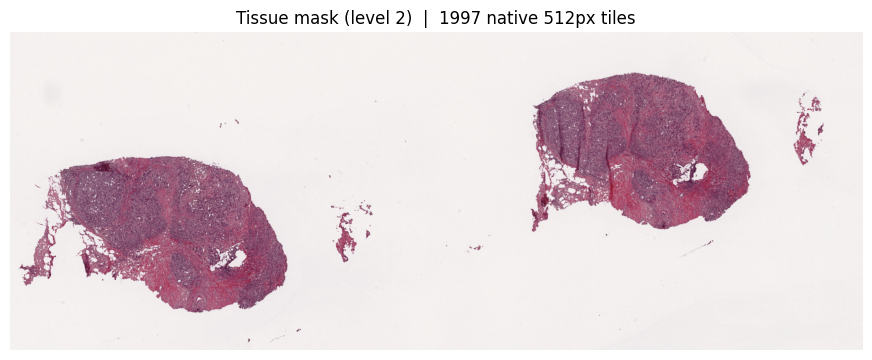

In [8]:
thumbnail_rgb, tissue_mask = build_tissue_mask(slide, tissue_level)
coords, GRID_W, GRID_H = generate_patch_coords(
    slide, tissue_mask, PATCH_SIZE, STRIDE, tissue_level, MIN_TISSUE_FRACTION, MAX_PATCHES)
print(f"Native {PATCH_SIZE}px grid: {GRID_W} x {GRID_H} = {GRID_W * GRID_H} total tiles")
print(f"Tissue tiles to run: {len(coords)}")

plt.figure(figsize=(11, 5))
plt.imshow(thumbnail_rgb)
plt.imshow(tissue_mask, alpha=0.30, cmap="Reds")
plt.title(f"Tissue mask (level {tissue_level})  |  {len(coords)} native {PATCH_SIZE}px tiles")
plt.axis("off"); plt.show()

Tiled inference + stitching

Each tile is read at **native level-0 `512 x 512`** and fed to the model **without any
resize** (split into `256x256` windows for the forward pass). The tile's full-resolution
`23 x 512 x 512` prediction is then downsampled to a `STITCH_BLOCK` block **only for the
slide-level canvas** and written at the tile's grid position.

In [9]:
def normalize_rgb(rgb):
    rgb = rgb.astype(np.float32) / 255.0
    return np.ascontiguousarray(np.transpose((rgb - MEAN) / STD, (2, 0, 1)))

@torch.no_grad()
def infer_tile(rgb_native):
    # rgb_native is the native 512x512 H&E tile -- NO resize before inference
    t = torch.from_numpy(normalize_rgb(rgb_native)).unsqueeze(0).to(device)
    _, _, H, W = t.shape
    logits = torch.zeros(1, NUM_CLASSES, H, W, device=device)
    for y in range(0, H, WINDOW_SIZE):
        for x in range(0, W, WINDOW_SIZE):
            logits[:, :, y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] = model(
                t[:, :, y:y + WINDOW_SIZE, x:x + WINDOW_SIZE].contiguous())
    return torch.sigmoid(logits).squeeze(0).cpu().numpy()

# slide-level stitched canvas: one STITCH_BLOCK block per grid cell, per channel
canvas = np.zeros((NUM_CLASSES, GRID_H * STITCH_BLOCK, GRID_W * STITCH_BLOCK), dtype=np.float32)
coverage = np.zeros((GRID_H * STITCH_BLOCK, GRID_W * STITCH_BLOCK), dtype=np.float32)

preview = None  # keep one full-resolution tile for a per-channel close-up
start = time.perf_counter()
for i, (x, y, gx, gy) in enumerate(coords):
    rgb = read_region_rgb(slide, INFERENCE_LEVEL, x, y, PATCH_SIZE, PATCH_SIZE)  # native, no resize
    pred = infer_tile(rgb)  # (23, 512, 512), sigmoid probs at native resolution
    # downsample ONLY for the slide-level canvas (visualization)
    block = np.stack([cv2.resize(pred[c], (STITCH_BLOCK, STITCH_BLOCK), interpolation=cv2.INTER_AREA)
                      for c in range(NUM_CLASSES)], axis=0)
    ys, xs = gy * STITCH_BLOCK, gx * STITCH_BLOCK
    canvas[:, ys:ys + STITCH_BLOCK, xs:xs + STITCH_BLOCK] = block
    coverage[ys:ys + STITCH_BLOCK, xs:xs + STITCH_BLOCK] = 1.0
    if preview is None:
        preview = (rgb, pred)
    if (i + 1) % 100 == 0 or (i + 1) == len(coords):
        print(f"  {i + 1}/{len(coords)} tiles | {time.perf_counter() - start:.1f}s", flush=True)

print("stitched canvas shape:", canvas.shape)

  100/1997 tiles | 4.9s


  200/1997 tiles | 9.5s


  300/1997 tiles | 14.1s


  400/1997 tiles | 18.8s


  500/1997 tiles | 24.7s


...

  1700/1997 tiles | 117.8s


  1800/1997 tiles | 125.4s


  1900/1997 tiles | 132.9s


  1997/1997 tiles | 140.8s


stitched canvas shape: (23, 480, 1272)


Slide-level virtual mIF across all channels

/var/folders/bk/q6m0vp457m92dd8lx22vvw7w0000gn/T/ipykernel_60049/1525707389.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab20", NUM_CLASSES)


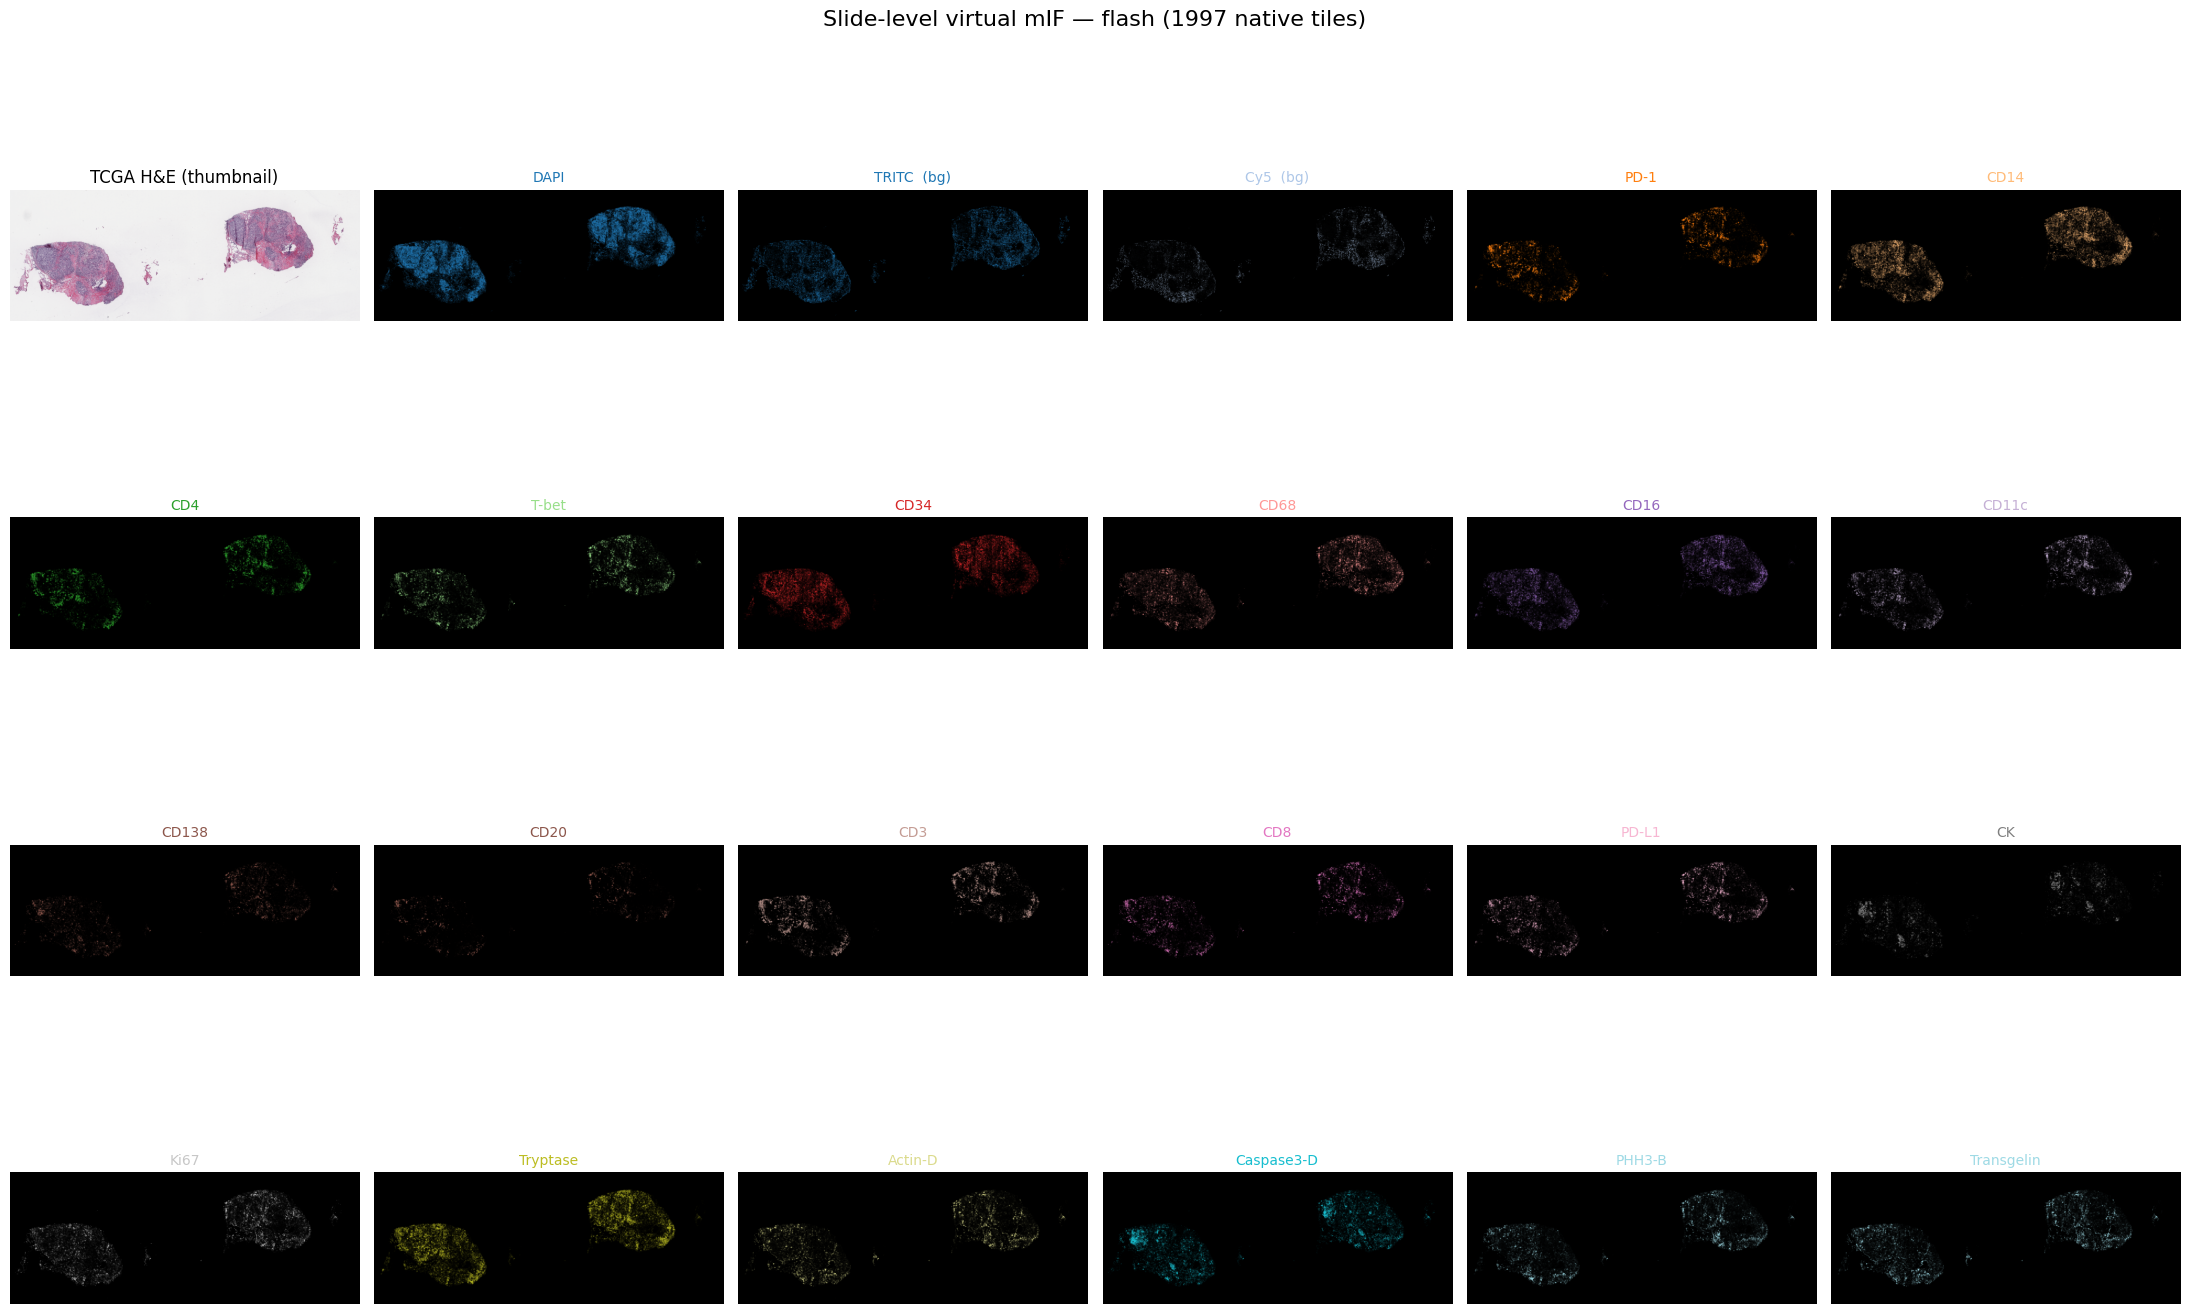

In [10]:
def colorize(mask_2d, color_hex, background=(0.0, 0.0, 0.0)):
    c = np.array(mcolors.to_rgb(color_hex), dtype=np.float32)
    bg = np.array(background, dtype=np.float32)
    m = np.clip(np.asarray(mask_2d, dtype=np.float32), 0.0, 1.0)
    return bg + m[..., None] * (c - bg)

palette = plt.cm.get_cmap("tab20", NUM_CLASSES)
channel_colors = {name: mcolors.to_hex(palette(i)) for i, name in enumerate(CHANNEL_NAMES)}

fig, axes = plt.subplots(4, 6, figsize=(22, 15))
axes = axes.ravel()
axes[0].imshow(thumbnail_rgb); axes[0].set_title("TCGA H&E (thumbnail)"); axes[0].axis("off")
for idx, name in enumerate(CHANNEL_NAMES):
    ax = axes[idx + 1]
    ch = canvas[idx].copy()
    lo, hi = np.percentile(ch[coverage > 0], [1, 99]) if (coverage > 0).any() else (0, 1)
    if hi <= lo: hi = lo + 1e-6
    ch = np.clip((ch - lo) / (hi - lo), 0, 1) * coverage
    ax.imshow(colorize(ch, channel_colors[name]))
    title = name + ("  (bg)" if name in BACKGROUND_CHANNELS else "")
    ax.set_title(title, color=channel_colors[name], fontsize=10)
    ax.axis("off")
fig.suptitle(f"Slide-level virtual mIF — {MODEL_VARIANT} ({len(coords)} native tiles)", fontsize=16)
plt.tight_layout(); plt.show()